In [1]:
# 7.6 Q2 - Go Out or Stay In (Weather Dataset)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv('datasets/weather_play.csv')
print("Shape:", df.shape)
print(df)
print()
print("Decision distribution:")
print(df['decision'].value_counts())

Shape: (14, 5)
     outlook temperature humidity    wind decision
0      Sunny         Hot     High    Weak   Go Out
1      Sunny         Hot     High  Strong  Stay In
2   Overcast         Hot     High    Weak   Go Out
3       Rain        Mild     High    Weak   Go Out
4       Rain        Cool   Normal    Weak   Go Out
5       Rain        Cool   Normal  Strong  Stay In
6   Overcast        Cool   Normal  Strong   Go Out
7      Sunny        Mild     High    Weak  Stay In
8      Sunny        Cool   Normal    Weak   Go Out
9       Rain        Mild   Normal    Weak   Go Out
10     Sunny        Mild   Normal  Strong   Go Out
11  Overcast        Mild     High  Strong   Go Out
12  Overcast         Hot   Normal    Weak   Go Out
13      Rain        Mild     High  Strong  Stay In

Decision distribution:
decision
Go Out     10
Stay In     4
Name: count, dtype: int64


In [4]:
# Encode categorical features

In [5]:
df_enc = df.copy()
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    encoders[col] = le

print(df_enc)
print()
print("Outlook  mapping:", dict(zip(encoders['outlook'].classes_,
                                    encoders['outlook'].transform(encoders['outlook'].classes_))))
print("Decision mapping:", dict(zip(encoders['decision'].classes_,
                                    encoders['decision'].transform(encoders['decision'].classes_))))

    outlook  temperature  humidity  wind  decision
0         2            1         0     1         0
1         2            1         0     0         1
2         0            1         0     1         0
3         1            2         0     1         0
4         1            0         1     1         0
5         1            0         1     0         1
6         0            0         1     0         0
7         2            2         0     1         1
8         2            0         1     1         0
9         1            2         1     1         0
10        2            2         1     0         0
11        0            2         0     0         0
12        0            1         1     1         0
13        1            2         0     0         1

Outlook  mapping: {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Decision mapping: {'Go Out': np.int64(0), 'Stay In': np.int64(1)}


In [6]:
X = df_enc[['outlook', 'temperature', 'humidity', 'wind']]
y = df_enc['decision']
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (14, 4) y shape: (14,)


In [7]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)
y_pred = model.predict(X)
print("Accuracy on full data:", accuracy_score(y, y_pred))
print()
print(classification_report(y, y_pred,
      target_names=encoders['decision'].classes_))

Accuracy on full data: 1.0

              precision    recall  f1-score   support

      Go Out       1.00      1.00      1.00        10
     Stay In       1.00      1.00      1.00         4

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



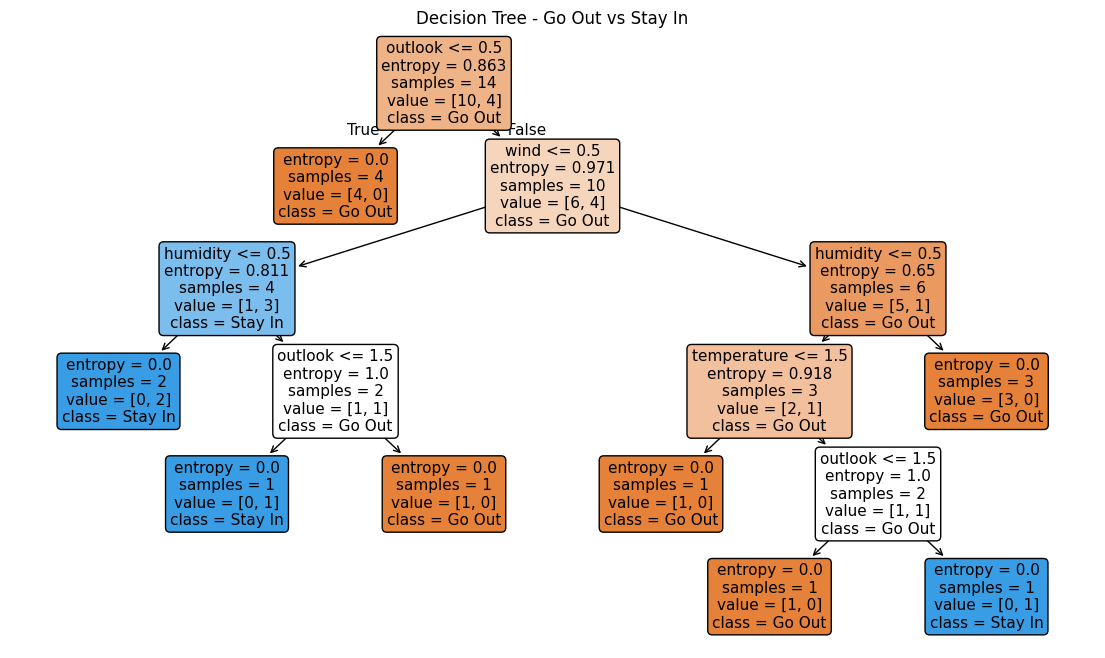

In [8]:
plt.figure(figsize=(14, 8))
plot_tree(model,
          feature_names=['outlook', 'temperature', 'humidity', 'wind'],
          class_names=list(encoders['decision'].classes_),
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree - Go Out vs Stay In')
plt.show()

In [9]:
# Predict for a new day

In [10]:
new_day = pd.DataFrame({
    'outlook':    ['Sunny'],
    'temperature':['Mild'],
    'humidity':   ['Normal'],
    'wind':       ['Weak'],
})
new_enc = pd.DataFrame({
    'outlook':    [encoders['outlook'].transform(['Sunny'])[0]],
    'temperature':[encoders['temperature'].transform(['Mild'])[0]],
    'humidity':   [encoders['humidity'].transform(['Normal'])[0]],
    'wind':       [encoders['wind'].transform(['Weak'])[0]],
})
pred = model.predict(new_enc)[0]
print("Sunny / Mild / Normal humidity / Weak wind  ->", encoders['decision'].classes_[pred])

Sunny / Mild / Normal humidity / Weak wind  -> Go Out
